# Credit Risk Modeling


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import confusion_matrix , accuracy_score, classification_report

import warnings
warnings.filterwarnings('ignore')

In [6]:
df = pd.read_csv('loan_detection.csv')
df

,age,campaign,pdays,previous,no_previous_contact,not_working,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,...,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success,Loan_Status_label
0,56,1,999,0,1,0,0,0,0,1,...,0,0,1,0,0,0,0,1,0,0
1,57,1,999,0,1,0,0,0,0,0,...,0,0,1,0,0,0,0,1,0,0
2,37,1,999,0,1,0,0,0,0,0,...,0,0,1,0,0,0,0,1,0,0
3,40,1,999,0,1,0,1,0,0,0,...,0,0,1,0,0,0,0,1,0,0
4,56,1,999,0,1,0,0,0,0,0,...,0,0,1,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,1,999,0,1,1,0,0,0,0,...,0,1,0,0,0,0,0,1,0,1
41184,46,1,999,0,1,0,0,1,0,0,...,0,1,0,0,0,0,0,1,0,0
41185,56,2,999,0,1,1,0,0,0,0,...,0,1,0,0,0,0,0,1,0,0
41186,44,1,999,0,1,0,0,0,0,0,...,0,1,0,0,0,0,0,1,0,1


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 60 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   age                            41188 non-null  int64
 1   campaign                       41188 non-null  int64
 2   pdays                          41188 non-null  int64
 3   previous                       41188 non-null  int64
 4   no_previous_contact            41188 non-null  int64
 5   not_working                    41188 non-null  int64
 6   job_admin.                     41188 non-null  int64
 7   job_blue-collar                41188 non-null  int64
 8   job_entrepreneur               41188 non-null  int64
 9   job_housemaid                  41188 non-null  int64
 10  job_management                 41188 non-null  int64
 11  job_retired                    41188 non-null  int64
 12  job_self-employed              41188 non-null  int64
 13  job_services    

In [19]:
df.columns

Index(['age', 'campaign', 'pdays', 'previous', 'no_previous_contact',
       'not_working', 'job_admin.', 'job_blue-collar', 'job_entrepreneur',
       'job_housemaid', 'job_management', 'job_retired', 'job_self-employed',
       'job_services', 'job_student', 'job_technician', 'job_unemployed',
       'job_unknown', 'marital_divorced', 'marital_married', 'marital_single',
       'marital_unknown', 'education_basic.4y', 'education_basic.6y',
       'education_basic.9y', 'education_high.school', 'education_illiterate',
       'education_professional.course', 'education_university.degree',
       'education_unknown', 'default_no', 'default_unknown', 'default_yes',
       'housing_no', 'housing_unknown', 'housing_yes', 'loan_no',
       'loan_unknown', 'loan_yes', 'contact_cellular', 'contact_telephone',
       'month_apr', 'month_aug', 'month_dec', 'month_jul', 'month_jun',
       'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep',
       'day_of_week_fri', 'day_of_week_mon'

In [20]:
df.shape

(41188, 60)

In [23]:
df.describe()

,age,campaign,pdays,previous,no_previous_contact,not_working,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,...,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success,Loan_Status_label
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,...,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,2.567593,962.475454,0.172963,0.963217,0.087623,0.253035,0.224677,0.035350,0.025736,...,0.013839,0.190031,0.206711,0.209357,0.196416,0.197485,0.103234,0.863431,0.033335,0.112654
std,10.42125,2.770014,186.910907,0.494901,0.188230,0.282749,0.434756,0.417375,0.184665,0.158348,...,0.116824,0.392330,0.404951,0.406855,0.397292,0.398106,0.304268,0.343396,0.179512,0.316173
min,17.00000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,32.00000,1.000000,999.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
50%,38.00000,2.000000,999.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
75%,47.00000,3.000000,999.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
max,98.00000,56.000000,999.000000,7.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# Imbalance data

In [25]:
df['Loan_Status_label']

0        0
1        0
2        0
3        0
4        0
        ..
41183    1
41184    0
41185    0
41186    1
41187    0
Name: Loan_Status_label, Length: 41188, dtype: int64

In [26]:
df['Loan_Status_label'].value_counts()

Loan_Status_label
0    36548
1     4640
Name: count, dtype: int64

In [27]:
print(round(len (df [df['Loan_Status_label'] == 0])/len (df), 2))

print(round(len(df [df[ 'Loan_Status_label']== 1])/len (df), 2))

0.89
0.11


In [37]:
for i in df.columns:
    if df[i].isnull().sum() > 0:
        print(f'-----------------------({i})-------------------------------\n')
        print(f'Mean - {df[i].mean()}')
        print(f'Median - {df[i].median()}\n')
        sns.distplot(df[i], color='b')
        plt.show()

In [38]:
for i in df.columns:
    if df[i].isnull().sum() > 0:
        print(f'{i} --> {df[i].mean()}')

In [39]:
df.duplicated().sum()

2417

-----------------------(i)-------------------------------



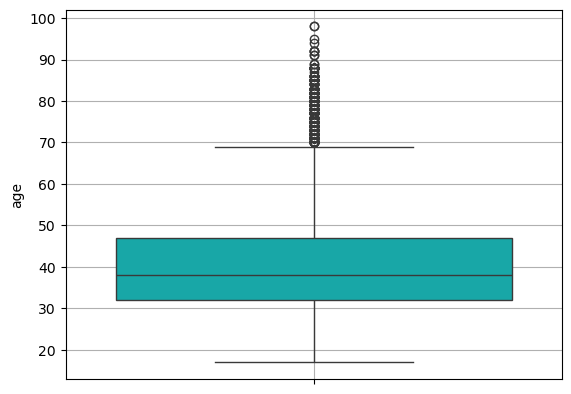

-----------------------(i)-------------------------------



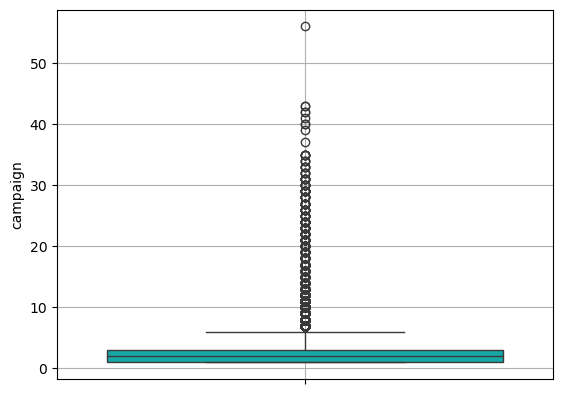

-----------------------(i)-------------------------------



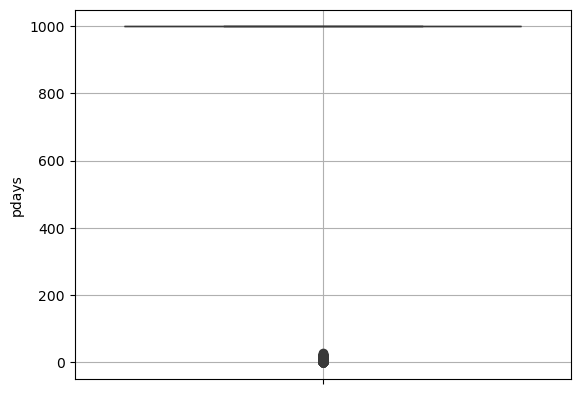

-----------------------(i)-------------------------------



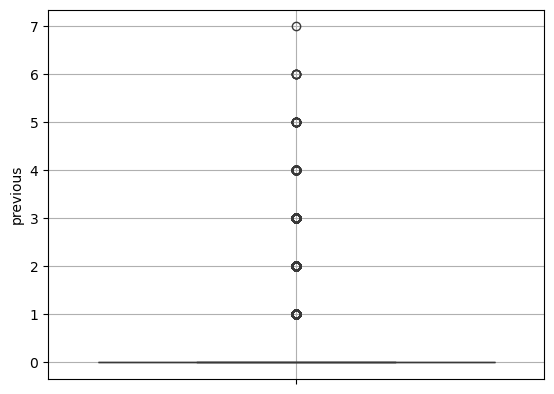

-----------------------(i)-------------------------------



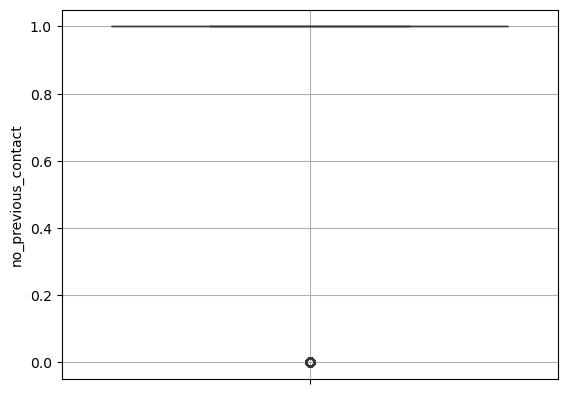

-----------------------(i)-------------------------------



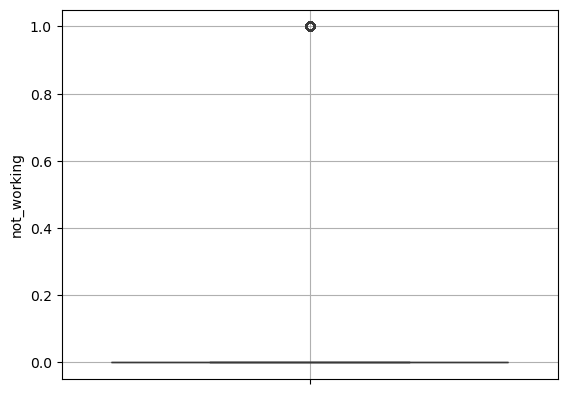

-----------------------(i)-------------------------------



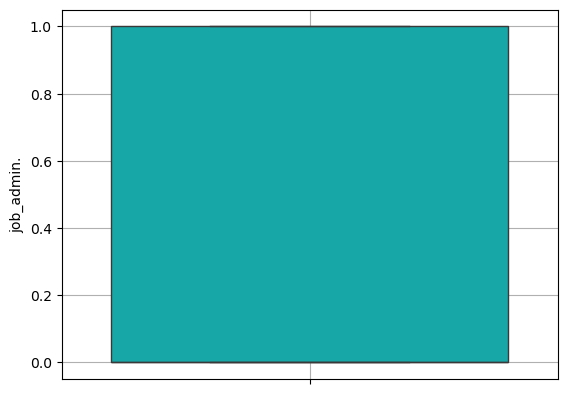

-----------------------(i)-------------------------------



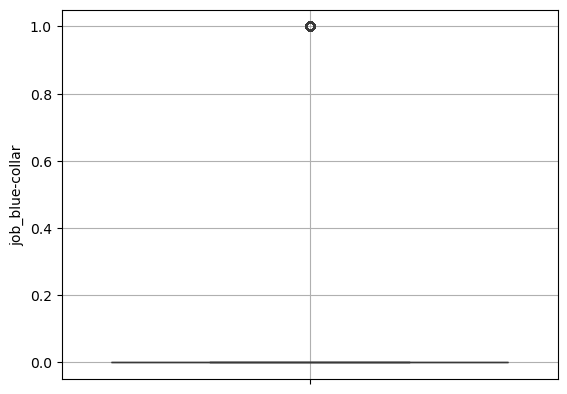

-----------------------(i)-------------------------------



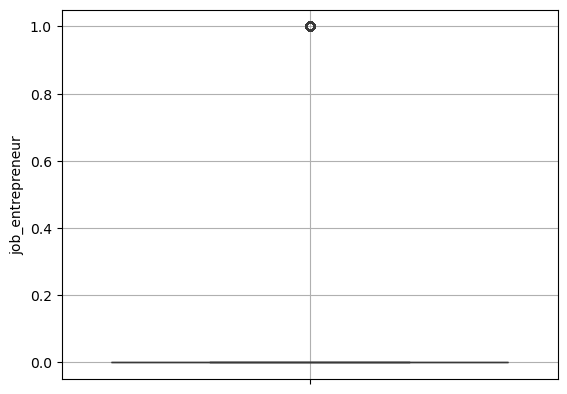

-----------------------(i)-------------------------------



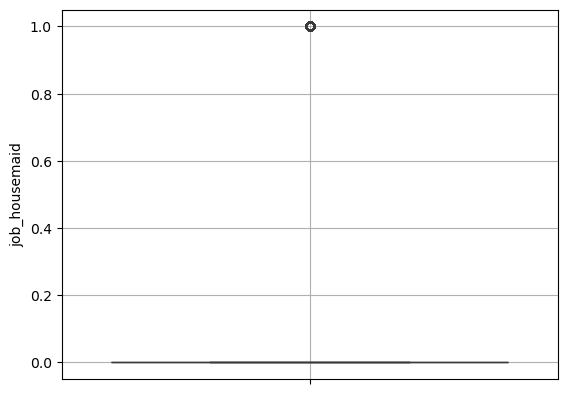

-----------------------(i)-------------------------------



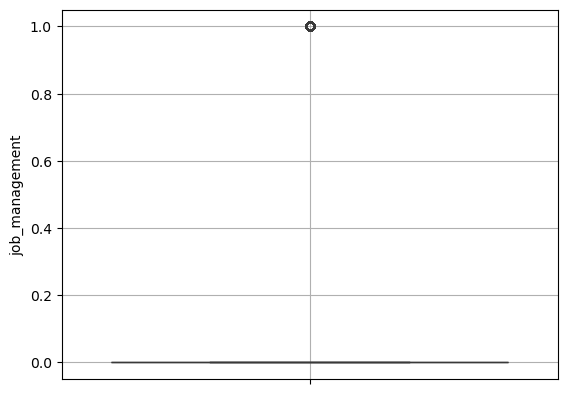

-----------------------(i)-------------------------------



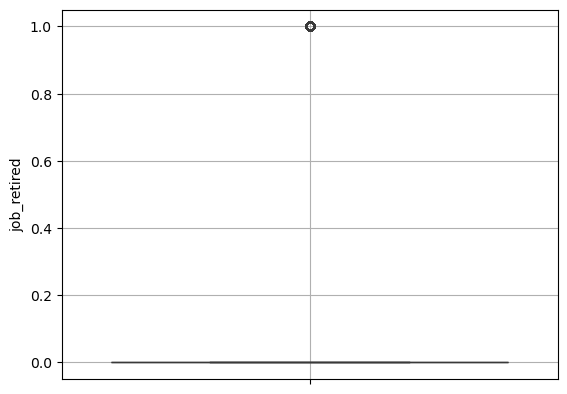

-----------------------(i)-------------------------------



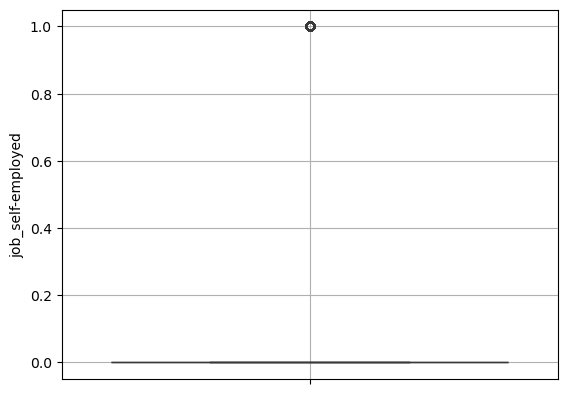

-----------------------(i)-------------------------------



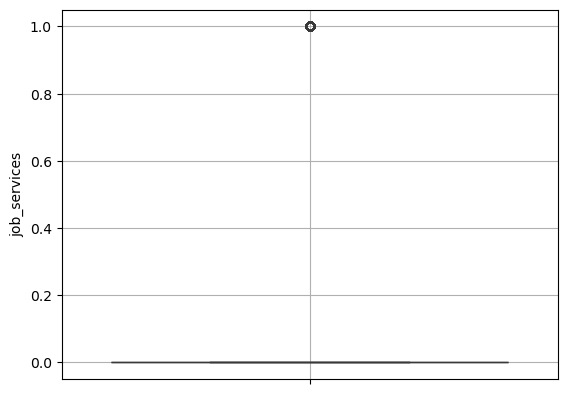

-----------------------(i)-------------------------------



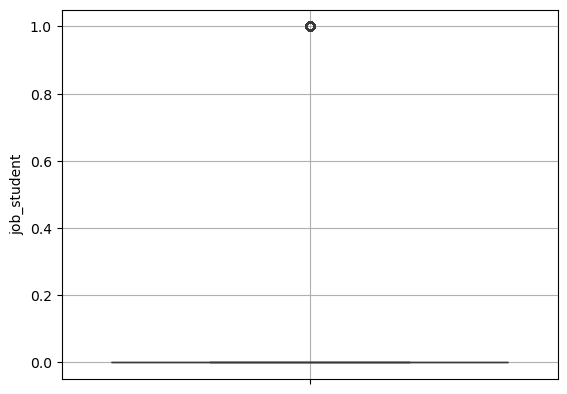

-----------------------(i)-------------------------------



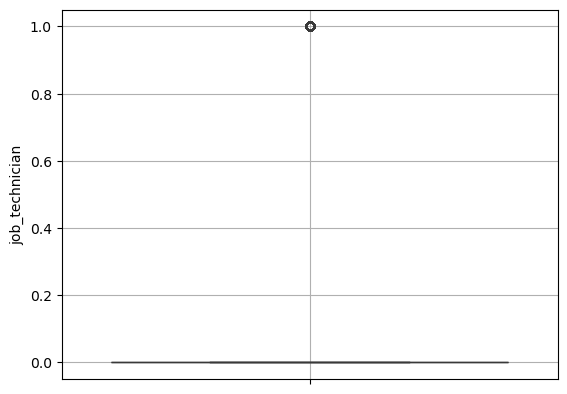

-----------------------(i)-------------------------------



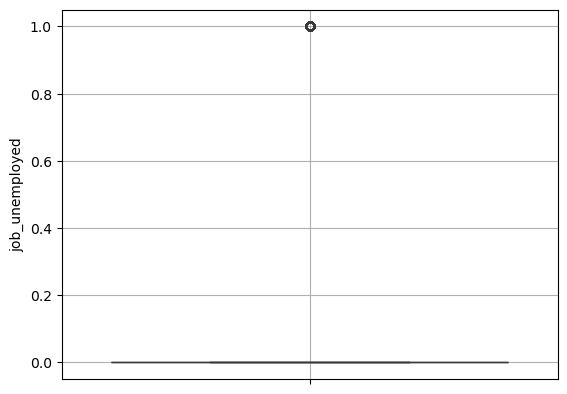

-----------------------(i)-------------------------------



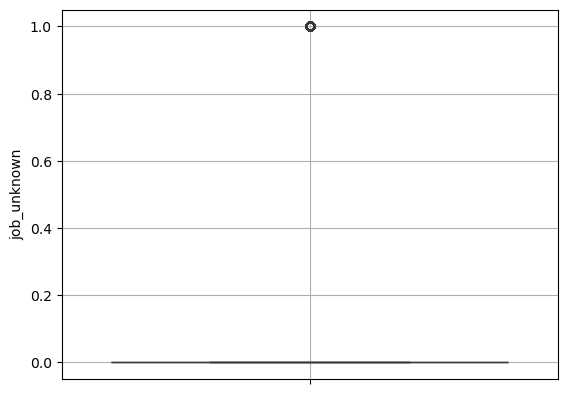

-----------------------(i)-------------------------------



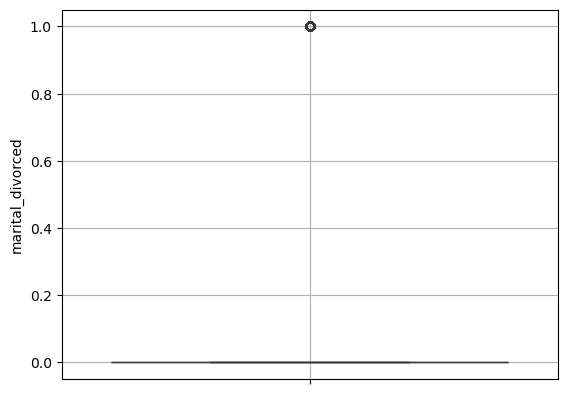

-----------------------(i)-------------------------------



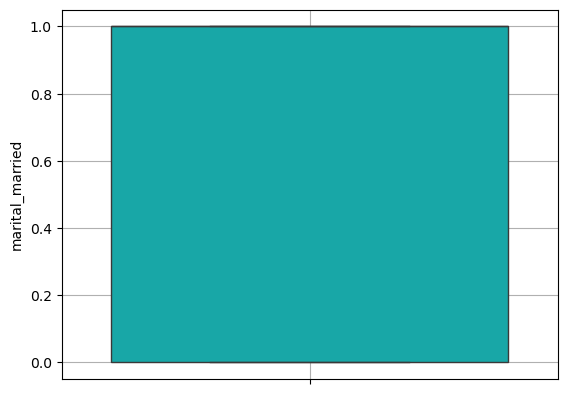

-----------------------(i)-------------------------------



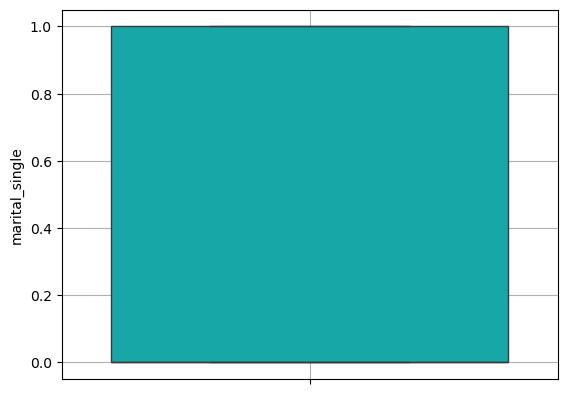

-----------------------(i)-------------------------------



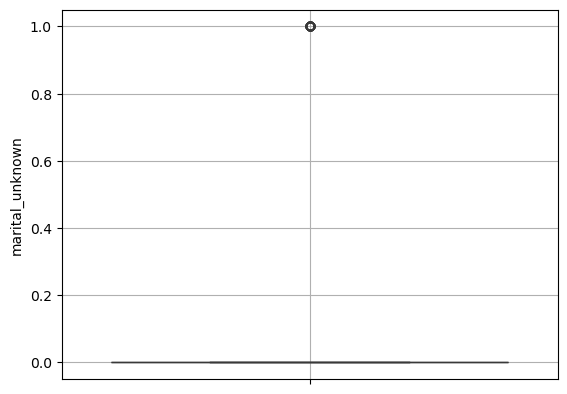

-----------------------(i)-------------------------------



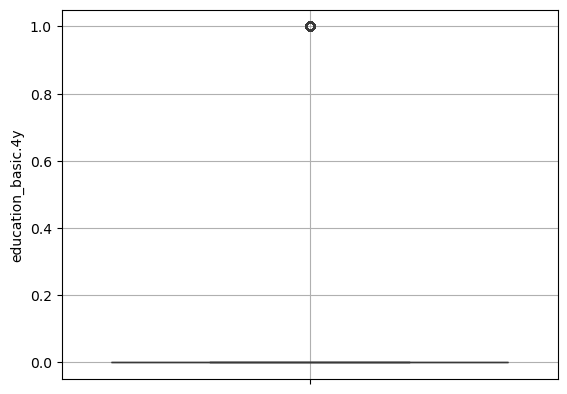

-----------------------(i)-------------------------------



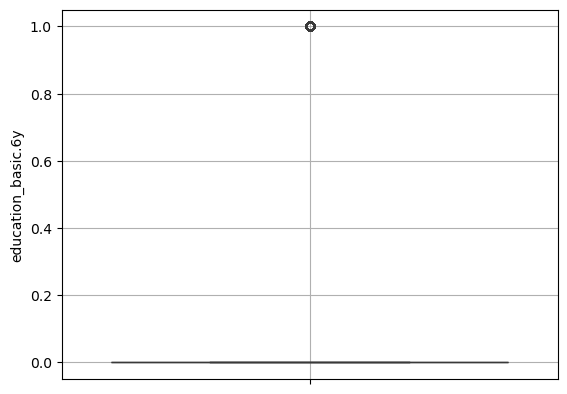

-----------------------(i)-------------------------------



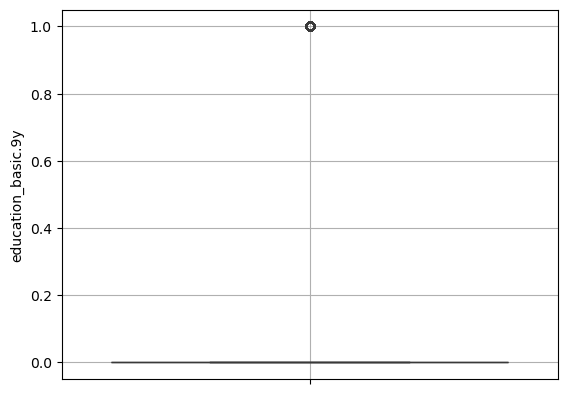

-----------------------(i)-------------------------------



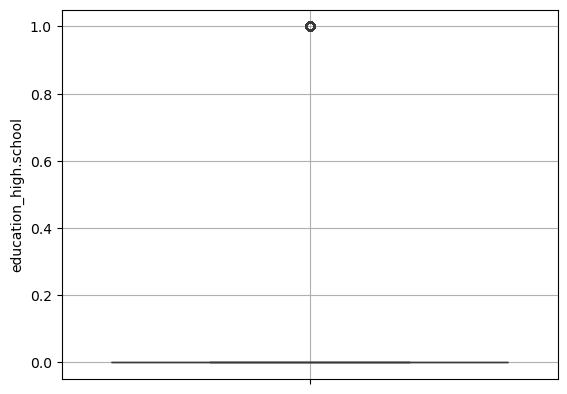

-----------------------(i)-------------------------------



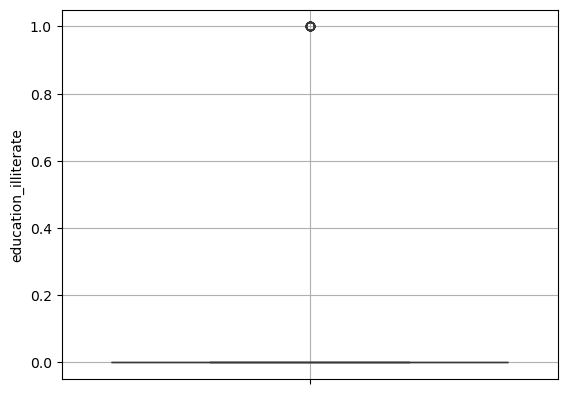

-----------------------(i)-------------------------------



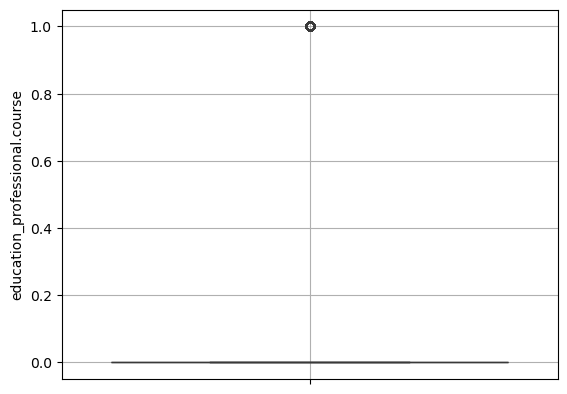

-----------------------(i)-------------------------------



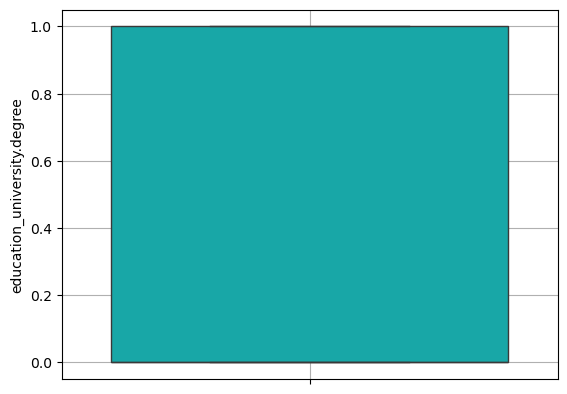

-----------------------(i)-------------------------------



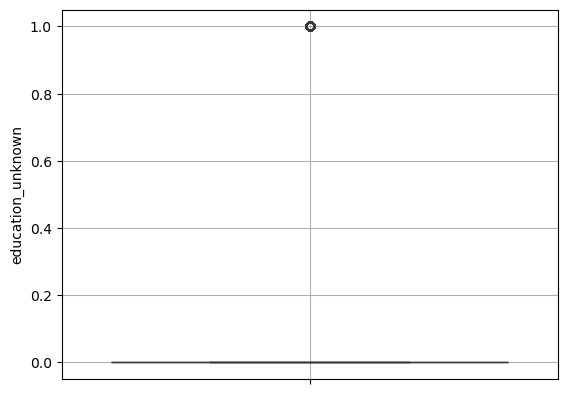

-----------------------(i)-------------------------------



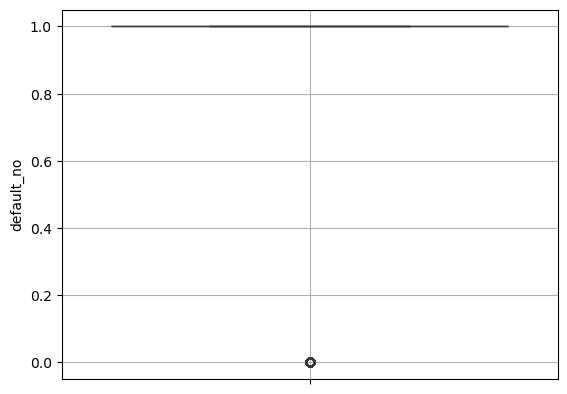

-----------------------(i)-------------------------------



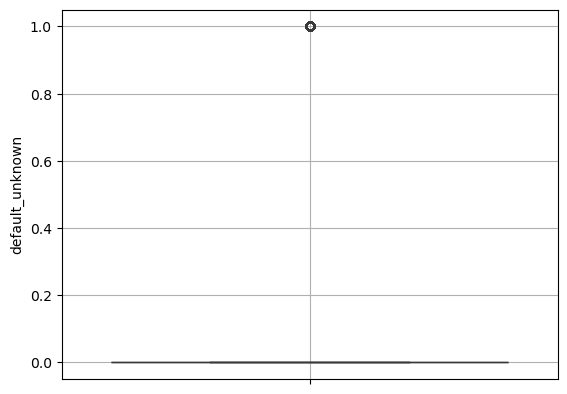

-----------------------(i)-------------------------------



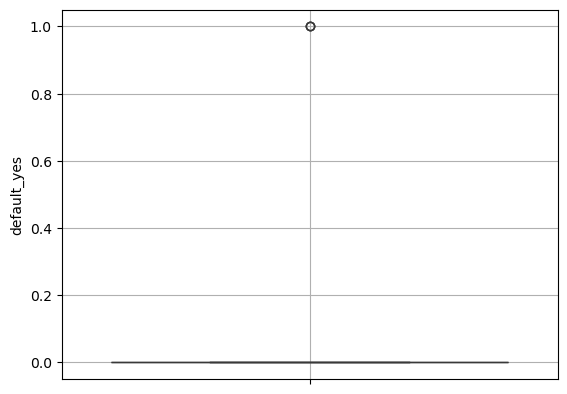

-----------------------(i)-------------------------------



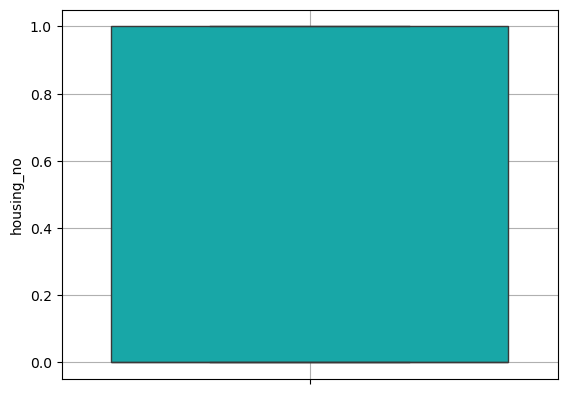

-----------------------(i)-------------------------------



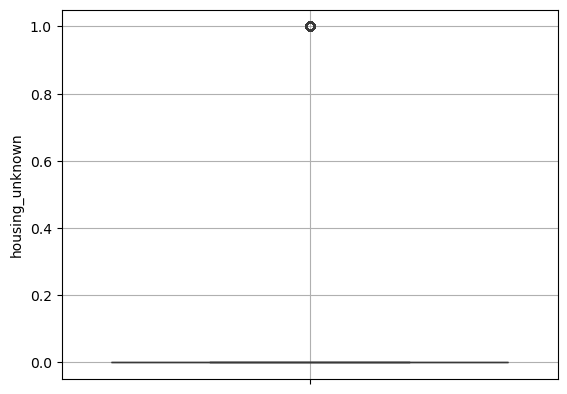

-----------------------(i)-------------------------------



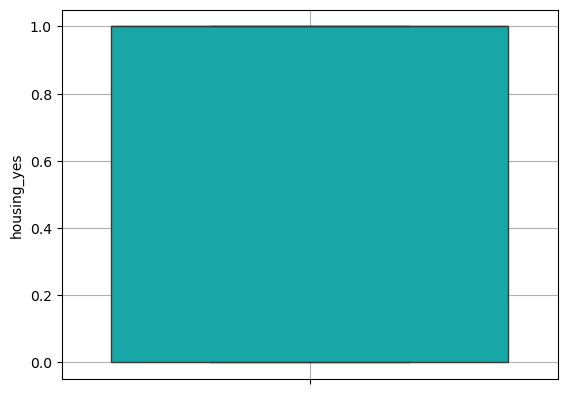

-----------------------(i)-------------------------------



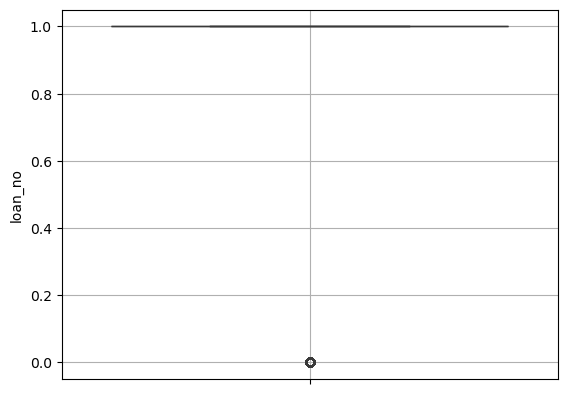

-----------------------(i)-------------------------------



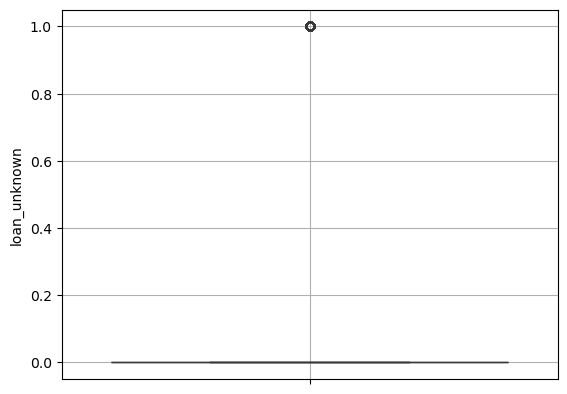

-----------------------(i)-------------------------------



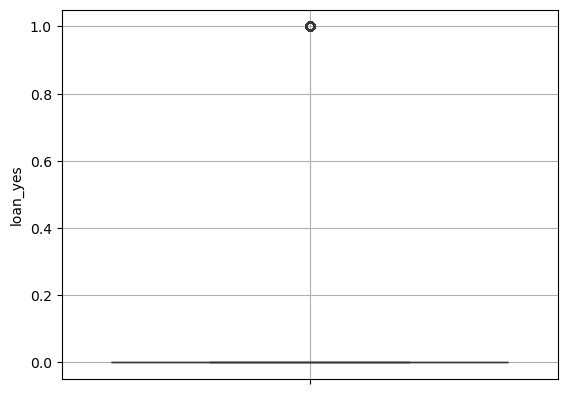

-----------------------(i)-------------------------------



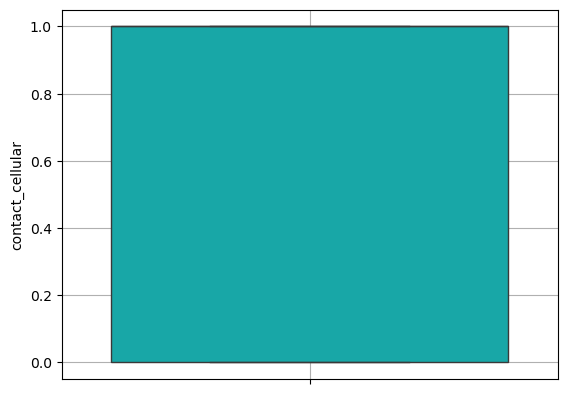

-----------------------(i)-------------------------------



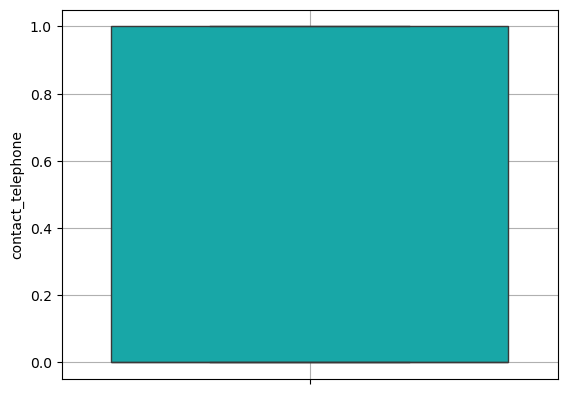

-----------------------(i)-------------------------------



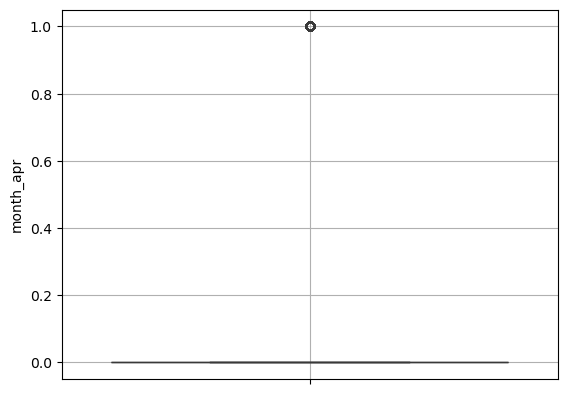

-----------------------(i)-------------------------------



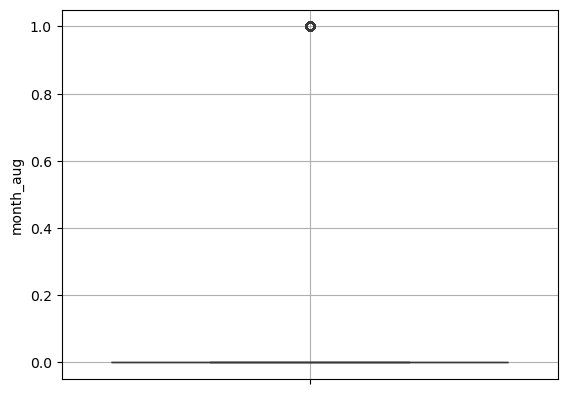

-----------------------(i)-------------------------------



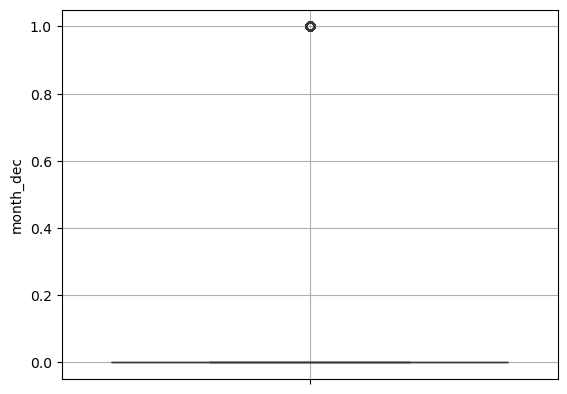

-----------------------(i)-------------------------------



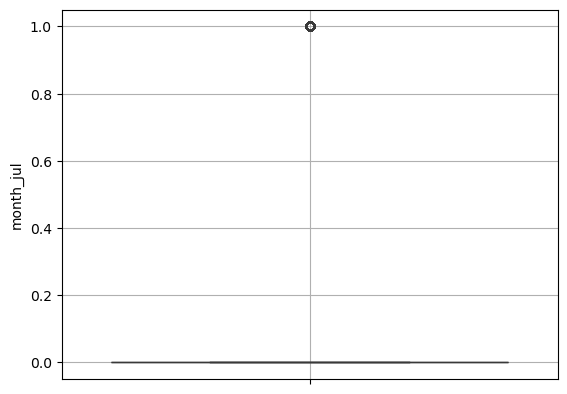

-----------------------(i)-------------------------------



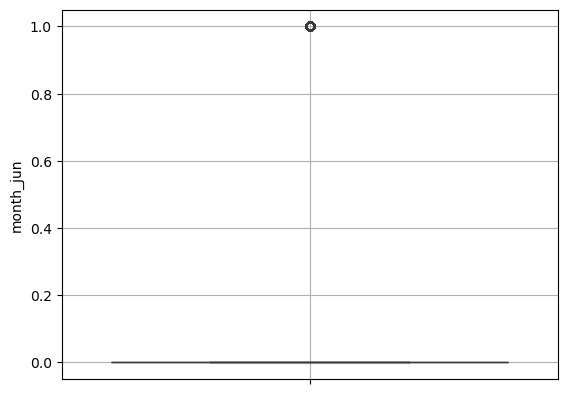

-----------------------(i)-------------------------------



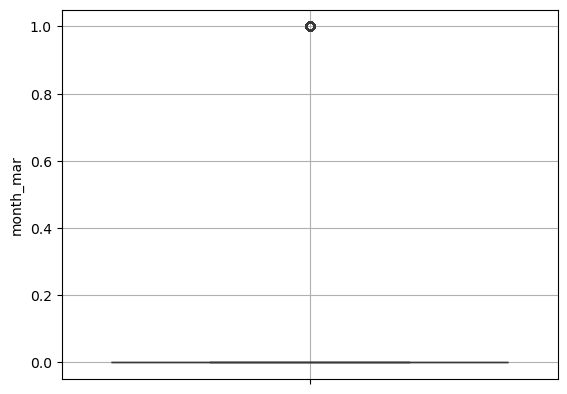

-----------------------(i)-------------------------------



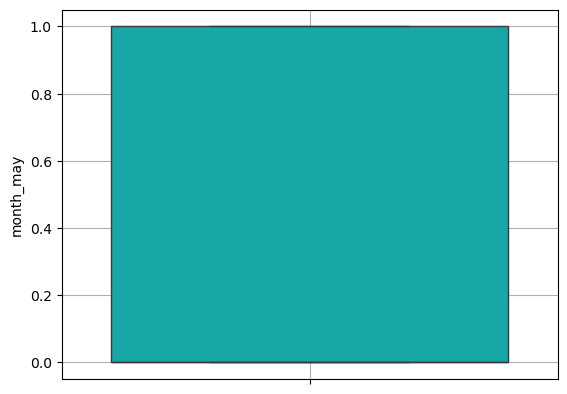

-----------------------(i)-------------------------------



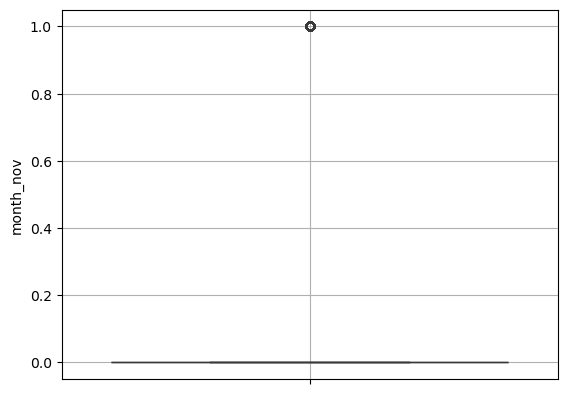

-----------------------(i)-------------------------------



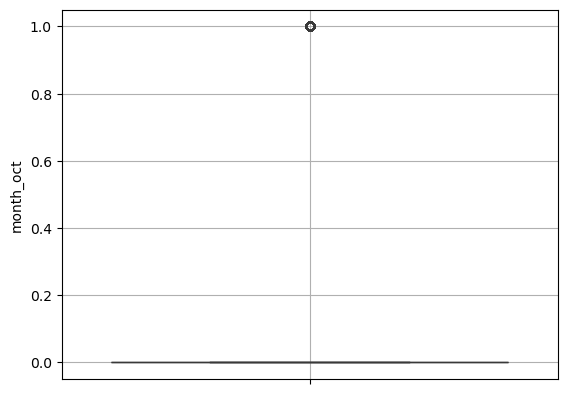

-----------------------(i)-------------------------------



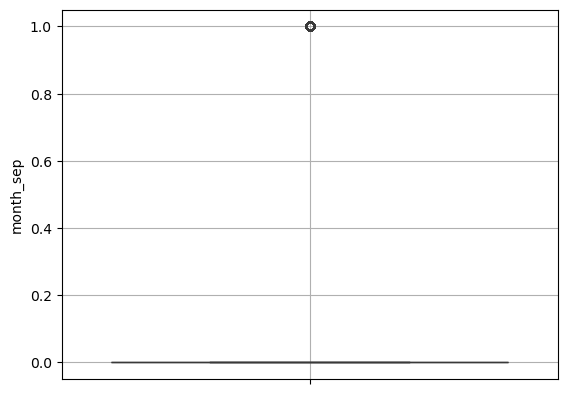

-----------------------(i)-------------------------------



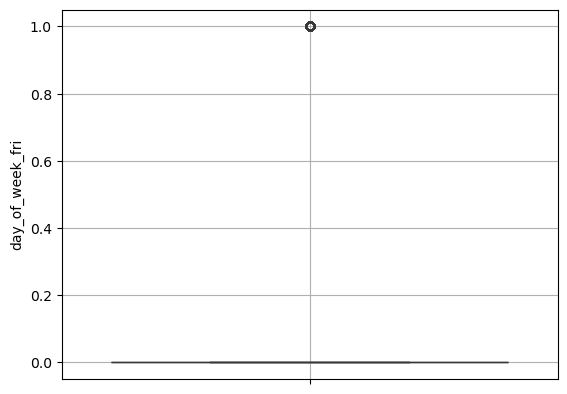

-----------------------(i)-------------------------------



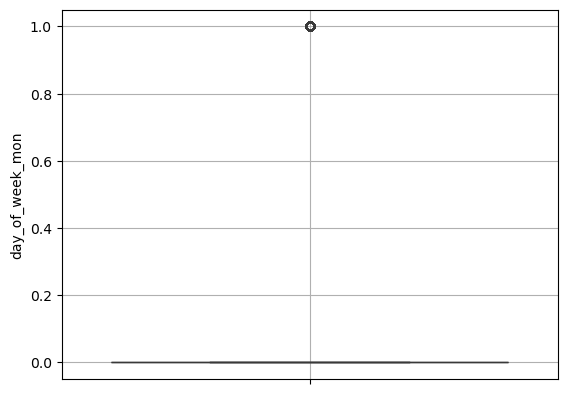

-----------------------(i)-------------------------------



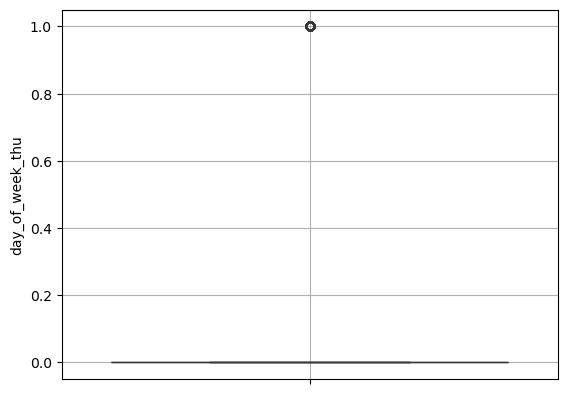

-----------------------(i)-------------------------------



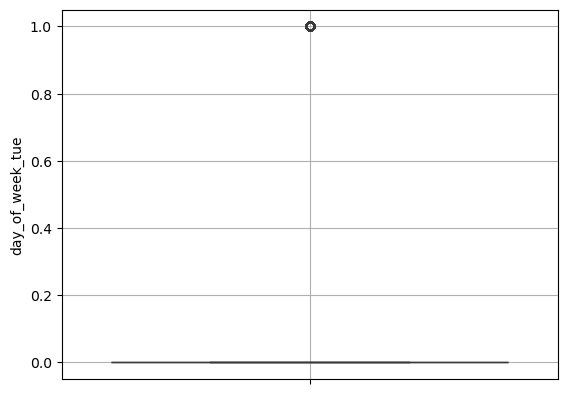

-----------------------(i)-------------------------------



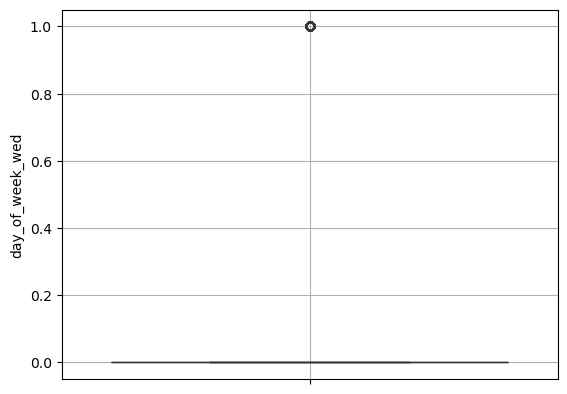

-----------------------(i)-------------------------------



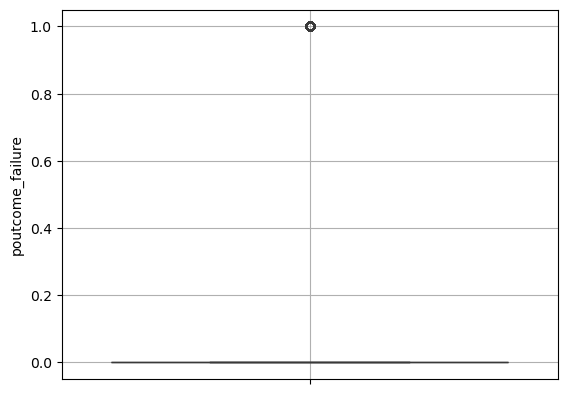

-----------------------(i)-------------------------------



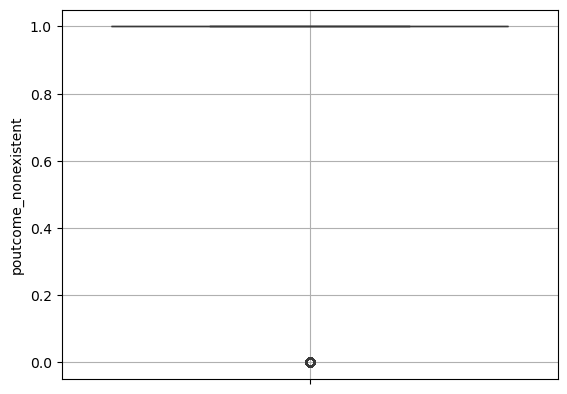

-----------------------(i)-------------------------------



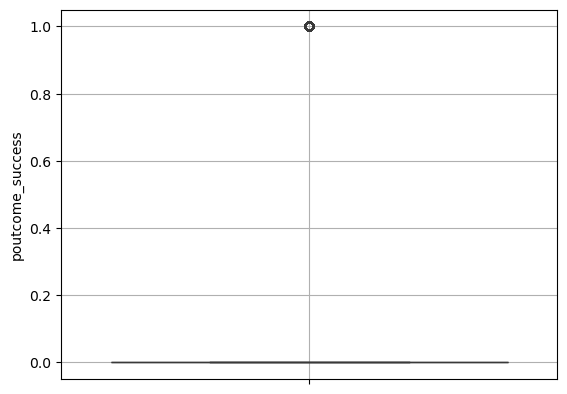

-----------------------(i)-------------------------------



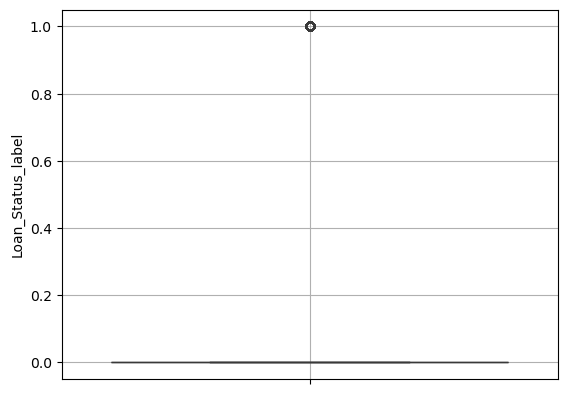

In [4]:
for i in df.columns:
    if i == ['previous','no_previous_contact','not_working','job_admin','job_blue-collar','job_entrepreneur','job_housemaid','month_sep','day_of_week_fri','day_of_week_mon','day_of_week_thu','day_of_week_tue','day_of_week_wed','poutcome_failure','poutcome_nonexistent','poutcome_success','Loan_Status_label'] :
        pass
    else:
        print(f'-----------------------(i)-------------------------------\n')
        sns.boxplot(df[i], color='c')
        plt.grid()
        plt.show()

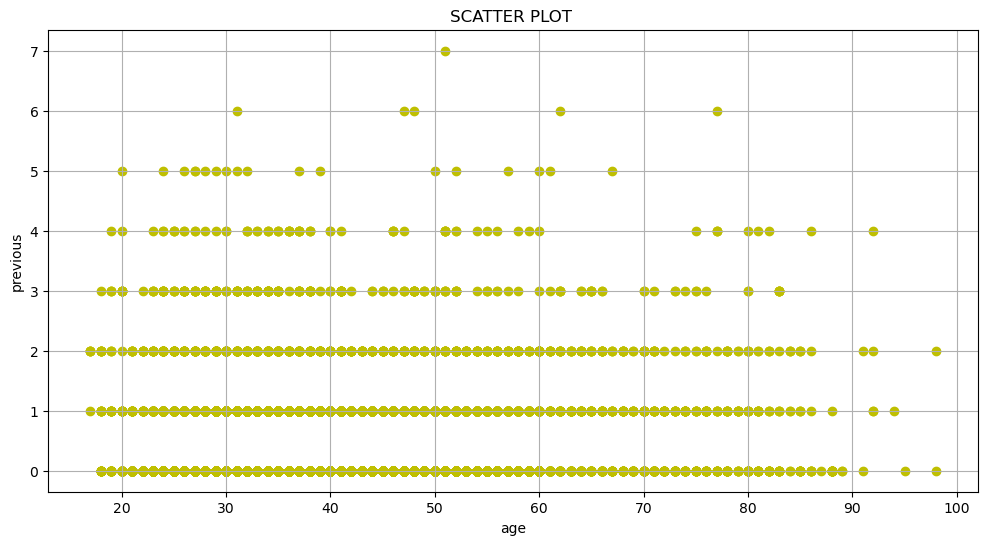

In [20]:
plt.figure(figsize=(12,6))
x=df['age']
y=df['previous']
plt.scatter(x,y,marker='o',color='y',label='previous')
plt.xlabel("age")
plt.ylabel("previous")
plt.title("SCATTER PLOT ")
plt.grid()
plt.show()

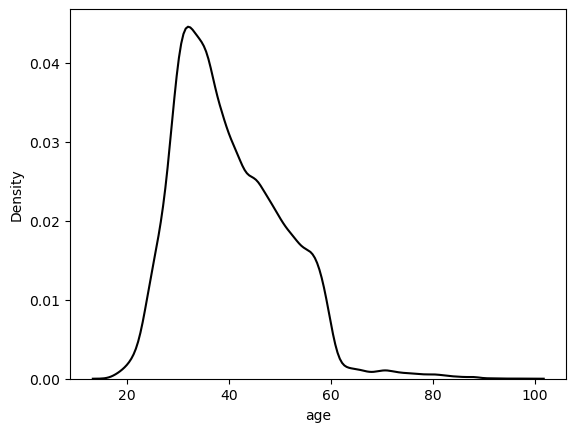

In [8]:
sns.kdeplot(df['age'],fill = False, color='black')
plt.show()

In [128]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)

IQR = Q3 - Q1
print(f'IQR : \n\n{IQR}')

IQR : 

age                              15.0
campaign                          2.0
pdays                             0.0
previous                          0.0
no_previous_contact               0.0
not_working                       0.0
job_admin.                        1.0
job_blue-collar                   0.0
job_entrepreneur                  0.0
job_housemaid                     0.0
job_management                    0.0
job_retired                       0.0
job_self-employed                 0.0
job_services                      0.0
job_student                       0.0
job_technician                    0.0
job_unemployed                    0.0
job_unknown                       0.0
marital_divorced                  0.0
marital_married                   1.0
marital_single                    1.0
marital_unknown                   0.0
education_basic.4y                0.0
education_basic.6y                0.0
education_basic.9y                0.0
education_high.school             0.0
educ

In [129]:
lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 - 1.5*IQR

print(f'lower_bound for outliers; \n\n{lower_bound}\n\n')
print(f'upper_bound for outliers; \n\n{upper_bound}\n\n')

lower_bound for outliers; 

age                                9.5
campaign                          -2.0
pdays                            999.0
previous                           0.0
no_previous_contact                1.0
not_working                        0.0
job_admin.                        -1.5
job_blue-collar                    0.0
job_entrepreneur                   0.0
job_housemaid                      0.0
job_management                     0.0
job_retired                        0.0
job_self-employed                  0.0
job_services                       0.0
job_student                        0.0
job_technician                     0.0
job_unemployed                     0.0
job_unknown                        0.0
marital_divorced                   0.0
marital_married                   -1.5
marital_single                    -1.5
marital_unknown                    0.0
education_basic.4y                 0.0
education_basic.6y                 0.0
education_basic.9y                 0

In [130]:
df.shape

(41188, 60)

In [133]:
df[~((df < lower_bound) | (df > upper_bound)).any(axis=1)]

,age,campaign,pdays,previous,no_previous_contact,not_working,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,...,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success,Loan_Status_label


In [127]:
df.corr()

,age,campaign,pdays,previous,no_previous_contact,not_working,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,...,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success,Loan_Status_label
age,1.000000,0.004594,-0.034369,0.024365,-0.034292,0.207547,-0.102584,-0.024191,0.031213,0.085403,...,0.040889,0.007148,0.019027,-0.021356,0.019137,-0.023671,-0.002537,-0.016376,0.035626,0.030399
campaign,0.004594,1.000000,0.052584,-0.079141,0.052569,-0.017529,0.011745,-0.001775,-0.002203,0.004226,...,-0.033953,0.026641,0.014405,0.005141,-0.025125,-0.021088,-0.068890,0.087645,-0.050893,-0.066357
pdays,-0.034369,0.052584,1.000000,-0.587514,0.999992,-0.112797,-0.025398,0.065335,0.019246,-0.001649,...,-0.154629,0.013782,0.001031,-0.008186,-0.007300,0.001021,0.006354,0.491353,-0.950700,-0.324914
previous,0.024365,-0.079141,-0.587514,1.000000,-0.587462,0.104066,0.018888,-0.054845,-0.013239,-0.011569,...,0.157651,0.004404,-0.002012,0.001512,0.000090,-0.003929,0.682608,-0.878776,0.524045,0.230181
no_previous_contact,-0.034292,0.052569,0.999992,-0.587462,1.000000,-0.112795,-0.025412,0.065328,0.019247,-0.001638,...,-0.154616,0.013775,0.001009,-0.008187,-0.007282,0.001033,0.006104,0.491357,-0.950283,-0.324877
not_working,0.207547,-0.017529,-0.112797,0.104066,-0.112795,1.000000,-0.180369,-0.166824,-0.059324,-0.050367,...,0.085305,0.002009,-0.005305,-0.002442,0.008890,-0.002960,0.032294,-0.083051,0.104134,0.121246
job_admin.,-0.102584,0.011745,-0.025398,0.018888,-0.025412,-0.180369,1.000000,-0.313313,-0.111417,-0.094595,...,0.010407,0.009892,-0.000736,-0.003970,-0.001835,-0.003112,0.002771,-0.015560,0.025069,0.031426
job_blue-collar,-0.024191,-0.001775,0.065335,-0.054845,0.065328,-0.166824,-0.313313,1.000000,-0.103050,-0.087492,...,-0.054309,0.003329,-0.009754,-0.007062,-0.006829,0.020673,-0.013254,0.043843,-0.061403,-0.074423
job_entrepreneur,0.031213,-0.002203,0.019246,-0.013239,0.019247,-0.059324,-0.111417,-0.103050,1.000000,-0.031113,...,-0.009172,-0.001905,0.006828,0.005551,-0.007275,-0.003480,0.001595,0.007598,-0.017238,-0.016644
job_housemaid,0.085403,0.004226,-0.001649,-0.011569,-0.001638,-0.050367,-0.094595,-0.087492,-0.031113,1.000000,...,-0.003503,-0.007595,0.003365,-0.009014,0.011500,0.001797,-0.017853,0.014629,0.002276,-0.006505


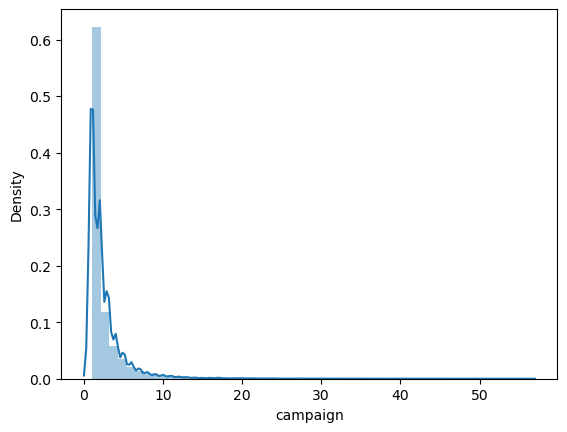

In [15]:
sns.distplot(df["campaign"])
plt.show()

In [11]:
plt.figure(figsize=(200,200))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm',)
plt.show()

# Model Building

In [7]:
df

,age,campaign,pdays,previous,no_previous_contact,not_working,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,...,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success,Loan_Status_label
0,56,1,999,0,1,0,0,0,0,1,...,0,0,1,0,0,0,0,1,0,0
1,57,1,999,0,1,0,0,0,0,0,...,0,0,1,0,0,0,0,1,0,0
2,37,1,999,0,1,0,0,0,0,0,...,0,0,1,0,0,0,0,1,0,0
3,40,1,999,0,1,0,1,0,0,0,...,0,0,1,0,0,0,0,1,0,0
4,56,1,999,0,1,0,0,0,0,0,...,0,0,1,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,1,999,0,1,1,0,0,0,0,...,0,1,0,0,0,0,0,1,0,1
41184,46,1,999,0,1,0,0,1,0,0,...,0,1,0,0,0,0,0,1,0,0
41185,56,2,999,0,1,1,0,0,0,0,...,0,1,0,0,0,0,0,1,0,0
41186,44,1,999,0,1,0,0,0,0,0,...,0,1,0,0,0,0,0,1,0,1


In [8]:
x = df.drop(columns=['Loan_Status_label'],axis=1)
y = df['Loan_Status_label']

In [13]:
x

,age,campaign,pdays,previous,no_previous_contact,not_working,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,...,month_oct,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success
0,56,1,999,0,1,0,0,0,0,1,...,0,0,0,1,0,0,0,0,1,0
1,57,1,999,0,1,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0
2,37,1,999,0,1,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0
3,40,1,999,0,1,0,1,0,0,0,...,0,0,0,1,0,0,0,0,1,0
4,56,1,999,0,1,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,1,999,0,1,1,0,0,0,0,...,0,0,1,0,0,0,0,0,1,0
41184,46,1,999,0,1,0,0,1,0,0,...,0,0,1,0,0,0,0,0,1,0
41185,56,2,999,0,1,1,0,0,0,0,...,0,0,1,0,0,0,0,0,1,0
41186,44,1,999,0,1,0,0,0,0,0,...,0,0,1,0,0,0,0,0,1,0


In [11]:
y

0        0
1        0
2        0
3        0
4        0
        ..
41183    1
41184    0
41185    0
41186    1
41187    0
Name: Loan_Status_label, Length: 41188, dtype: int64

In [11]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [17]:

x_train[:3]

,age,campaign,pdays,previous,no_previous_contact,not_working,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,...,month_oct,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success
12556,40,2,999,0,1,0,0,1,0,0,...,0,0,0,1,0,0,0,0,1,0
35451,31,4,999,0,1,0,1,0,0,0,...,0,0,0,1,0,0,0,0,1,0
30592,59,6,999,1,1,1,0,0,0,0,...,0,0,0,1,0,0,0,1,0,0


In [18]:
x_test[:4]

,age,campaign,pdays,previous,no_previous_contact,not_working,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,...,month_oct,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success
32884,57,1,999,1,1,0,0,0,0,0,...,0,0,0,1,0,0,0,1,0,0
3169,55,2,999,0,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
32206,33,1,999,1,1,0,0,1,0,0,...,0,0,1,0,0,0,0,1,0,0
9403,36,4,999,0,1,0,1,0,0,0,...,0,0,1,0,0,0,0,0,1,0


In [9]:
from sklearn.preprocessing import StandardScaler

In [12]:
sc=StandardScaler()
X_train_sc=sc.fit_transform(x_train)
X_test_sc=sc.fit_transform(x_test)

In [24]:
print(X_train_sc)

[[-1.66930454e-03 -2.06241614e-01  1.94660673e-01 ... -3.40481710e-01
   3.98373809e-01 -1.84965343e-01]
 [-8.64094846e-01  5.13675879e-01  1.94660673e-01 ... -3.40481710e-01
   3.98373809e-01 -1.84965343e-01]
 [ 1.81900684e+00  1.23359337e+00  1.94660673e-01 ...  2.93701532e+00
  -2.51020518e+00 -1.84965343e-01]
 ...
 [-4.80794606e-01 -5.66200360e-01 -5.14775262e+00 ... -3.40481710e-01
  -2.51020518e+00  5.40641820e+00]
 [-1.66930454e-03 -2.06241614e-01  1.94660673e-01 ... -3.40481710e-01
   3.98373809e-01 -1.84965343e-01]
 [-1.05574497e+00 -2.06241614e-01  1.94660673e-01 ... -3.40481710e-01
   3.98373809e-01 -1.84965343e-01]]


In [56]:
X_test_sc

array([[ 1.63562386, -0.56486335,  0.19840223, ...,  2.98952736,
        -2.53145677, -0.18861365],
       [ 1.44262285, -0.19952267,  0.19840223, ..., -0.33450104,
         0.39502946, -0.18861365],
       [-0.68038832, -0.56486335,  0.19840223, ...,  2.98952736,
        -2.53145677, -0.18861365],
       ...,
       [ 0.57411828,  3.45388416,  0.19840223, ...,  2.98952736,
        -2.53145677, -0.18861365],
       [-0.87338934, -0.19952267,  0.19840223, ..., -0.33450104,
         0.39502946, -0.18861365],
       [ 1.82862488, -0.19952267,  0.19840223, ..., -0.33450104,
         0.39502946, -0.18861365]])

# Model Selection

In [16]:
lr = LogisticRegression()
lr.fit(X_train_sc, y_train)

print(f'Training accuracy : {round(lr.score(X_train_sc, y_train), 2)*100}%')
print(f'Test accuracy : {round(lr.score(X_test_sc, y_test), 2)*100}%')

Training accuracy : 90.0%
Test accuracy : 90.0%


In [19]:
dtree = DecisionTreeClassifier(max_depth=5)
dtree.fit(X_train_sc, y_train);
print(f'Training accuracy : {round(dtree.score(X_train_sc, y_train), 2)*100}%')
print(f'Test accuracy : {round(dtree.score(X_test_sc, y_test), 2)*100}%')

Training accuracy : 90.0%
Test accuracy : 89.0%


In [68]:
y_pred_train = dtree.predict(X_train_sc)
y_pred_test = dtree.predict(X_test_sc)

In [22]:
x_train[:3]

,age,campaign,pdays,previous,no_previous_contact,not_working,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,...,month_oct,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success
12556,40,2,999,0,1,0,0,1,0,0,...,0,0,0,1,0,0,0,0,1,0
35451,31,4,999,0,1,0,1,0,0,0,...,0,0,0,1,0,0,0,0,1,0
30592,59,6,999,1,1,1,0,0,0,0,...,0,0,0,1,0,0,0,1,0,0


In [73]:
y_train[:3]

12556    0
35451    0
30592    0
Name: Loan_Status_label, dtype: int64

In [75]:
y_pred_train[:3]

array([0, 0, 0], dtype=int64)

In [76]:
confusion_matrix(y_train, y_pred_train)

array([[28803,   442],
       [ 2806,   899]], dtype=int64)

<Axes: >

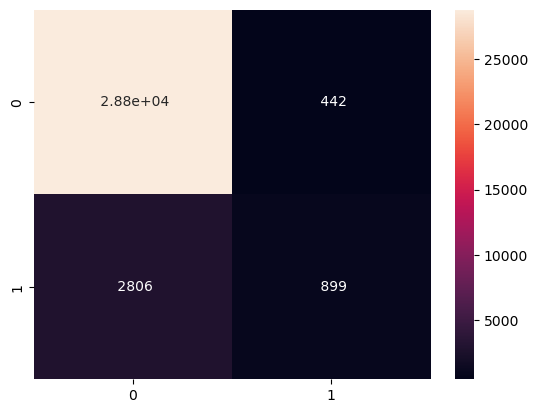

In [78]:
sns.heatmap(confusion_matrix(y_train, y_pred_train), annot=True, fmt=' .4g')

In [80]:
accuracy_score(y_train, y_pred_train)

0.9014264036418816

In [99]:
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.91      0.98      0.94      7303
           1       0.61      0.20      0.30       935

    accuracy                           0.89      8238
   macro avg       0.76      0.59      0.62      8238
weighted avg       0.87      0.89      0.87      8238



In [120]:
new_data = [[68, 4, 909, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1 ,0, 1, 0, 1, 0, 0, 1, 1 ,0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1]]
new_data

[[68,
  4,
  909,
  0,
  1,
  0,
  1,
  0,
  1,
  1,
  0,
  1,
  0,
  1,
  0,
  0,
  1,
  1,
  0,
  1,
  0,
  1,
  0,
  0,
  1,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  0,
  1,
  1,
  0,
  1,
  1,
  0,
  1,
  0,
  1,
  1,
  0,
  1,
  0,
  1,
  0,
  0,
  1,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  1]]

In [121]:
dtree.predict(new_data)

array([0], dtype=int64)